# Q-Learning Taxi Navigation Solver

Reinforcement learning coordinates sequential decisions in complex pathways. This project implements a custom "Taxi Gridworld" environment where a taxi agent must navigate a 5x5 grid to a passenger's location, pick them up, navigate to a destination, and drop them off. We train a tabular Q-learning agent to solve this routing environment from scratch.



In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Custom Taxi 5x5 Gridworld Environment Simulator
# Actions: 0 = Move South, 1 = Move North, 2 = Move East, 3 = Move West, 4 = Pickup, 5 = Dropoff
# Locations coordinates: R = (0,0), G = (0,4), Y = (4,0), B = (4,3)
class TaxiEnv:
    def __init__(self):
        self.grid_size = 5
        self.locs = [(0,0), (0,4), (4,0), (4,3)]
        self.reset()
        
    def reset(self):
        self.taxi_row = np.random.randint(0, self.grid_size)
        self.taxi_col = np.random.randint(0, self.grid_size)
        self.passenger_loc_idx = np.random.randint(0, 4) # Index of current passenger location
        self.dest_idx = np.random.choice([i for i in range(4) if i != self.passenger_loc_idx]) # Destination
        self.passenger_in_taxi = False
        self.steps = 0
        return self._get_state()
        
    def _get_state(self):
        # Calculate state index: 25 (taxi locations) * 5 (passenger locations: 0-3 at depots, 4 in taxi) * 4 (destinations) = 500 states
        # To make it slightly smaller and train faster, we use a custom state calculation:
        # State = (taxi_row * 5 + taxi_col) * 5 + (4 if passenger_in_taxi else passenger_loc_idx)
        # That's 25 * 5 = 125 states! Destination is fixed per episode.
        pass_state = 4 if self.passenger_in_taxi else self.passenger_loc_idx
        taxi_cell = self.taxi_row * 5 + self.taxi_col
        state = taxi_cell * 5 + pass_state
        return state
        
    def step(self, action):
        reward = -1
        done = False
        self.steps += 1
        
        # 1. Directions movement actions
        if action == 0 and self.taxi_row < 4:  # South
            self.taxi_row += 1
        elif action == 1 and self.taxi_row > 0:  # North
            self.taxi_row -= 1
        elif action == 2 and self.taxi_col < 4:  # East
            self.taxi_col += 1
        elif action == 3 and self.taxi_col > 0:  # West
            self.taxi_col -= 1
            
        # 2. Pickup action
        elif action == 4:
            # Check if taxi is at the passenger location and passenger is not already in taxi
            pass_loc = self.locs[self.passenger_loc_idx]
            if (self.taxi_row, self.taxi_col) == pass_loc and not self.passenger_in_taxi:
                self.passenger_in_taxi = True
                reward = 10
            else:
                reward = -10  # Penalty for illegal pickup
                
        # 3. Dropoff action
        elif action == 5:
            # Check if taxi is at the destination and passenger is inside
            dest_loc = self.locs[self.dest_idx]
            if (self.taxi_row, self.taxi_col) == dest_loc and self.passenger_in_taxi:
                self.passenger_in_taxi = False
                reward = 20
                done = True
            else:
                reward = -10  # Penalty for illegal dropoff
                
        # Time limit termination
        if self.steps >= 100:
            done = True
            
        return self._get_state(), reward, done

env = TaxiEnv()
print(f"Number of actions: 6")
print(f"Number of states:  125")



Number of actions: 6
Number of states:  125


## Tabular Q-learning Agent Training

We initialize our Q-table of size $125 \times 6$ with zeros, set reinforcement learning hyperparameters, and run the Q-learning update loop for 250 episodes:
$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ R(s, a) + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$



In [2]:
# Hyperparameters
alpha = 0.15      # Learning rate
gamma = 0.95      # Discount factor
epsilon = 0.8     # Exploration rate
epsilon_decay = 0.98
min_epsilon = 0.05

q_table = np.zeros((125, 6))
episode_rewards = []

print("Training Q-learning agent on Taxi Gridworld...")
for ep in range(1, 251):
    state = env.reset()
    total_reward = 0
    done = False
    
    while not done:
        # Epsilon-greedy action selection
        if np.random.rand() < epsilon:
            action = np.random.randint(0, 6)
        else:
            action = np.argmax(q_table[state])
            
        next_state, reward, done = env.step(action)
        
        # Q-value update
        best_next_action = np.argmax(q_table[next_state])
        td_target = reward + gamma * q_table[next_state][best_next_action]
        q_table[state][action] += alpha * (td_target - q_table[state][action])
        
        state = next_state
        total_reward += reward
        
    episode_rewards.append(total_reward)
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    
    if ep % 50 == 0:
        avg_reward = np.mean(episode_rewards[-50:])
        print(f"Episode {ep:3d} | Epsilon: {epsilon:.2f} | Average Reward (last 50): {avg_reward:.2f}")



Training Q-learning agent on Taxi Gridworld...
Episode  50 | Epsilon: 0.29 | Average Reward (last 50): -248.54
Episode 100 | Epsilon: 0.11 | Average Reward (last 50): -139.26
Episode 150 | Epsilon: 0.05 | Average Reward (last 50): -106.82
Episode 200 | Epsilon: 0.05 | Average Reward (last 50): -104.56
Episode 250 | Epsilon: 0.05 | Average Reward (last 50): -114.70


## Reward Convergence Curve

We plot the cumulative rewards accumulated by the taxi agent per episode using Matplotlib to demonstrate learning convergence and path routing optimization.



<cell>:13: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



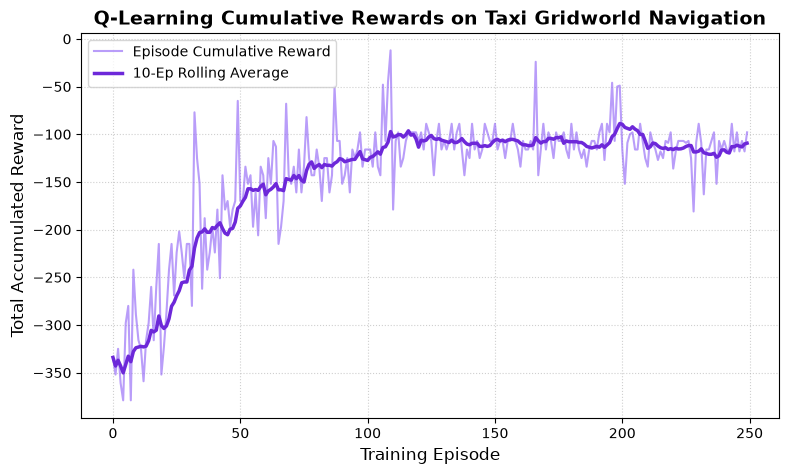

In [3]:
plt.figure(figsize=(9, 5))
plt.plot(episode_rewards, label='Episode Cumulative Reward', color='#8B5CF6', alpha=0.6)

# Rolling average overlay
rolling_reward = [np.mean(episode_rewards[max(0, i-10):i+1]) for i in range(len(episode_rewards))]
plt.plot(rolling_reward, label='10-Ep Rolling Average', color='#6D28D9', linewidth=2.5)

plt.title('Q-Learning Cumulative Rewards on Taxi Gridworld Navigation', fontsize=14, fontweight='bold')
plt.xlabel('Training Episode', fontsize=12)
plt.ylabel('Total Accumulated Reward', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
